In [45]:
# import
import pandas as pd
import numpy as np
import re
import os
import joblib
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [46]:
# load
career_df = pd.read_csv("career_dataset_large_cleaned.csv")

career_df.head()

,Specialization,Certifications,CGPA/Percentage,Skills_ID_Categorized,Recommended_Career,Education_Level_ID_Categorized,Certifications_ID_Categorized
0,Finance,Tally ERP,67,"Konseling, MS Office, Machine Learning",Business Analyst,Sarjana,Keuangan & ERP
1,Science,AWS Certified,67,"Keuangan & Akuntansi, MS Office",Software Engineer,SMA/Sederajat,Cloud bersertifikat (AWS)
2,Business,Mental Health Basics,90,"Analisis Data & IT, Keuangan & Akuntansi, SQL",Financial Analyst,Magister,Kesehatan Mental
3,Computer Science,No Certification,75,Komunikasi,Staf Administrasi,Sarjana,Tanpa Sertifikat
4,Business,Tally ERP,83,Analisis Data & IT,Asisten Penjualan,SMA/Sederajat,Keuangan & ERP


In [47]:
# drop duplicate
career_df = career_df.drop_duplicates().copy()

career_df.shape

(4998, 7)

In [48]:
# feature & target
career_df["combined_features"] = (
    career_df["Specialization"].astype(str) + " " +
    career_df["Skills_ID_Categorized"].astype(str) + " " +
    career_df["Certifications"].astype(str) + " " +
    career_df["Education_Level_ID_Categorized"].astype(str)
)

In [49]:
X = career_df["combined_features"]
y = career_df["Recommended_Career"]

In [50]:
# text cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

X_cleaned = X.apply(clean_text)

In [51]:
# TF - IDF
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2)
)
X_tfidf = tfidf.fit_transform(X_cleaned)

X_tfidf.shape

(4998, 264)

In [52]:
# label encoding
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

num_classes = len(encoder.classes_)

print("Jumlah class:", num_classes)
print(encoder.classes_)

Jumlah class: 12
['Akademisi/Dosen' 'Akuntan Junior' 'Asisten Penjualan' 'Business Analyst'
 'Eksekutif Pemasaran' 'Financial Analyst' 'Ilmuwan Peneliti'
 'Konselor Sekolah' 'ML Engineer' 'Operator Entri Data'
 'Software Engineer' 'Staf Administrasi']


In [53]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3998, 264)
X_test : (1000, 264)
y_train: (3998,)
y_test : (1000,)


In [54]:
# convert sparse matrix ke array
X_train_array = X_train.toarray()
X_test_array = X_test.toarray()

In [55]:
# build baseline model
input_dim = X_train_array.shape[1]

model = models.Sequential([

    layers.Input(shape=(input_dim,)),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),

    layers.Dense(num_classes, activation="softmax")
])

In [56]:
# compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [57]:
# training model
history = model.fit(
    X_train_array,
    y_train,
    validation_data=(X_test_array, y_test),
    epochs=35,
    batch_size=32
)

Epoch 1/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0780 - loss: 2.4879 - val_accuracy: 0.0930 - val_loss: 2.4839
Epoch 2/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0953 - loss: 2.4805 - val_accuracy: 0.0850 - val_loss: 2.4838
Epoch 3/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1116 - loss: 2.4725 - val_accuracy: 0.0780 - val_loss: 2.4894
Epoch 4/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1241 - loss: 2.4577 - val_accuracy: 0.0880 - val_loss: 2.4999
Epoch 5/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1361 - loss: 2.4361 - val_accuracy: 0.0860 - val_loss: 2.5085
Epoch 6/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1546 - loss: 2.3999 - val_accuracy: 0.0800 - val_loss: 2.5249
Epoch 7/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1763 - loss: 2.3613 - val_accuracy: 0.0840 - val_loss: 2.5459
Epoch 8/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1883 - loss: 2.3222 - val_accuracy: 0.

In [58]:
#evaluate model
loss, accuracy = model.evaluate(X_test_array, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0900 - loss: 3.8576 
Test Loss: 3.8576254844665527
Test Accuracy: 0.09000000357627869


In [59]:
# classification report
y_pred_prob = model.predict(X_test_array)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_,
    zero_division=0
))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                     precision    recall  f1-score   support

    Akademisi/Dosen       0.04      0.05      0.05        81
     Akuntan Junior       0.13      0.10      0.11        83
  Asisten Penjualan       0.10      0.11      0.10        83
   Business Analyst       0.07      0.04      0.05        79
Eksekutif Pemasaran       0.14      0.13      0.13        86
  Financial Analyst       0.12      0.12      0.12        83
   Ilmuwan Peneliti       0.08      0.10      0.09        84
   Konselor Sekolah       0.10      0.12      0.11        83
        ML Engineer       0.06      0.05      0.05        86
Operator Entri Data       0.08      0.07      0.08        83
  Software Engineer       0.08      0.10      0.09        83
  Staf Administrasi       0.08      0.10      0.09        86

           accuracy                           0.09      1000
          macro avg       0.09      0.09      0.09      1000
       weighted avg       0.09      0.09    

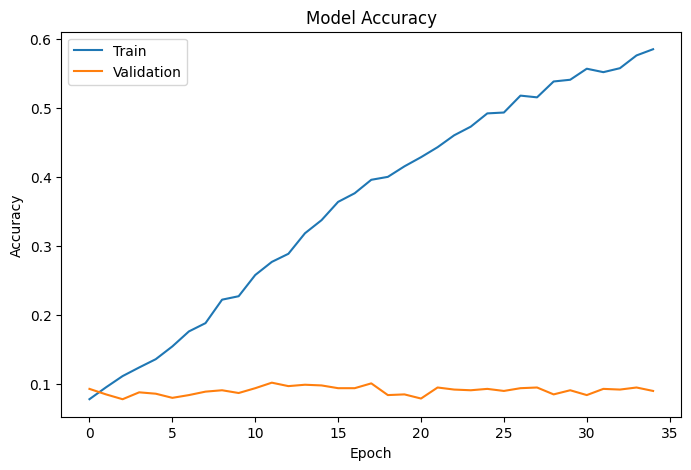

In [60]:
# training visualization - accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

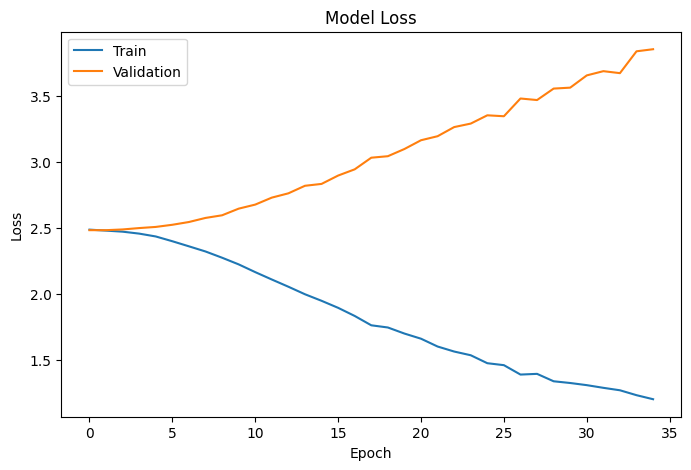

In [61]:
# Training visualization - loss
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

In [62]:
#manual interface test

sample_skill = ["python sql machine learning data analysis"]

sample_cleaned = [clean_text(sample_skill[0])]
sample_vector = tfidf.transform(sample_cleaned).toarray()

prediction = model.predict(sample_vector)
predicted_label = np.argmax(prediction, axis=1)
predicted_career = encoder.inverse_transform(predicted_label)

print("Predicted Career:", predicted_career[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted Career: Eksekutif Pemasaran


In [63]:
#save model dan artifact
sample_skill = ["python sql machine learning data analysis"]

sample_cleaned = [clean_text(sample_skill[0])]
sample_vector = tfidf.transform(sample_cleaned).toarray()

prediction = model.predict(sample_vector)
predicted_label = np.argmax(prediction, axis=1)
predicted_career = encoder.inverse_transform(predicted_label)

print("Predicted Career:", predicted_career[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted Career: Eksekutif Pemasaran


In [64]:
os.makedirs("models", exist_ok=True)

model.save("models/career_recommendation_model_large.keras")
joblib.dump(tfidf, "models/tfidf_vectorizer_large.pkl")
joblib.dump(encoder, "models/label_encoder_large.pkl")

['models/label_encoder_large.pkl']

## Kesimpulan Baseline Modeling

Model baseline berhasil dikembangkan menggunakan TensorFlow untuk memprediksi `Recommended_Career` berdasarkan fitur `Skills_ID_Categorized`. Data teks diproses menggunakan TF-IDF, sedangkan label target dikonversi menggunakan LabelEncoder. Model ini menjadi baseline awal untuk sistem rekomendasi karir pada proyek AI Career Navigator.